## KV-Caching

Useful during inference

**The Bottleneck: Standard Inference**

* In standard autoregressive generation, the model re-processes the entire sequence for every new token.
    * Complexity: $O(n^2)$
    * Waste: $K$ and $V$ matrices for "past" tokens are re-computed at every step, even though they never change (due to the causal mask).

**The Solution: KV-Caching**

* By storing $K$ and $V$ tensors during the "prefill" phase, we transform the decoding process.
    * Complexity: $O(n)$
    * Geometry Shift: Attention changes from a square $n \times n$ matrix to a rectangular $1 \times n$ matrix.
    * Dynamic Masking: Implementation requires "slicing" the causal mask to match the current token's absolute position in the timeline.

---
  


1. Standard Inference: For each new token, the entire sequence (prompt + previously generated tokens) is re-processed through the Multi-Head Attention (MHA) module. This involves re-calculating $K$ and $V$ matrices for all tokens at every step, leading to $O(n^2)$ complexity.
2. KV-Cache Inference: During the "prefill" phase, $K$ and $V$ tensors for the prompt are computed and stored. For subsequent "decoding" steps, only the single new token is processed to generate its $Q, K, V$ vectors. The new $K$ and $V$ are appended to the cache, and attention is computed as a $1 \times n$ operation, reducing complexity to $O(n)$.

Implementation:
* Masking Logic: Implemented dynamic mask slicing to align the $(1, n)$ attention scores with the causal triangle.
* Positional Encoding: Manually updated token indices during cached iterations to ensure correct relative attention.

Results:

Metric,Standard Inference,KV-Cache Inference,Improvement
Total Execution Time,19.22s,3.97s,~4.8x Speedup
Tokens per Second,~0.52 tps,~2.52 tps,+380%

Performance Boost:
* Inference goes from O(n^2) to O(n)
* The "Linear" Advantage: While memory usage increases linearly with the cache, the reduction in FLOPs (Floating Point Operations) is the primary driver of the speedup.
* Memory-Compute Trade-off: KV-caching trades VRAM for speed. For large-scale production (like YouTube-scale infrastructure), managing this "KV-cache memory pressure" is the central challenge of LLM serving.
* Geometry Shift: The shift from a square $n \times n$ attention matrix to a rectangular $1 \times n$ matrix is the fundamental mechanical change that enables this efficiency.

While $O(n)$ is better than $O(n^2)$, the KV-cache size eventually hits the context window limit (e.g., 1024), at which point we must implement sliding window eviction or pagination logic.

### Concrete Example

Imagine each "unit of work" is the model processing a single token through its layers.

1. Standard Inference ($O(n^2)$)
    * Every time the model generates a new token, it has to re-read everything that came before it.
    * Step 1: Process 2 tokens (the prompt) $\rightarrow$ get token 3.
    * Step 2: Process 3 tokens $\rightarrow$ get token 4.
    * Step 1,000: Process 1,001 tokens $\rightarrow$ get token 1,002.
    * Total Work: $\approx \sum_{i=2}^{1000} i \approx \mathbf{500,000}$ units of work.
   
2. KV-Cache Inference ($O(n)$)
    * The model only does the heavy lifting for the prompt once, then coasts.
    * Prefill: Process 2 tokens once $\rightarrow$ Cache $K$ and $V$.
    * Step 1 to 1,000: In each step, the model only processes 1 new token and looks at the cache.
    * Total Work: $2 (\text{prefill}) + 1,000 (\text{decoding}) = \mathbf{1,002}$ units of work.

The Result: For a 1,000-token generation, the KV-cache is doing roughly 500x less work. The 2-token prefill is just a tiny blip at the very beginning.

In [1]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False,      # Query-key-value bias
    "weight_tying": False
}

In [2]:
import torch
from gpt_model import GPTModel
import tiktoken

In [3]:
# detect what hardware is available
# basically, detect the best fastest available processor
# on our computer so that your GPT model doesn't run at 
# a snail's pace on the CPU if a better option exists.

# check for an NVIDIA graphics card with CUDA drivers installed
# GOLD STANDARD
if torch.cuda.is_available():
    device = torch.device("cuda")
# check for apple GPUs built into M1, M2 or M3 chips
elif torch.backends.mps.is_available():
    # Only use GPU on a mac if the PyTorch supports it
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
# fallback to CPU
else:
    device = torch.device("cpu")

print(f"Using {device} device.")

Using cpu device.


In [4]:
# load the model weights

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("trained_model.pt", map_location=device))
model.to(device)
model.eval()

GPTModel(
  (sem_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (layerNorm1): LayerNorm()
      (mha): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (layerNorm2): LayerNorm()
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
  )
  (final_norm): LayerNorm()
  (out_head): Linear(in_features=768, out_feat

In [5]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

import time
from generate_text import generate_text_simple, generate_text_with_kv_cache
from tokenization_helper import token_ids_to_text, text_to_token_ids

# Benchmark Original (Standard)
t0 = time.time()
output_token_ids = generate_text_simple(
    model,
    text_to_token_ids(start_context, tokenizer),
    max_new_tokens=100,
    context_size=256,
)
print(f"Standard Time: {time.time() - t0:.4f}s")
print(token_ids_to_text(output_token_ids, tokenizer))

# Benchmark Optimized (KV-Cache)
t1 = time.time()
output_token_ids = generate_text_with_kv_cache(
    model,
    text_to_token_ids(start_context, tokenizer),
    max_new_tokens=100,
    context_size=256,
)
print(f"KV-Cache Time: {time.time() - t1:.4f}s")
print(token_ids_to_text(output_token_ids, tokenizer))

Standard Time: 15.7474s
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

He laughed again, and threw back his head to the donkey again. I saw that, and down the room, when I couldn't look at that, with the cry on my lips, my diagnosis suffered an unexpected check.

"Oh, a balancing, I was _the_ fashionable painter."

"Ah, and I was when I got Mrs. St
KV-Cache Time: 4.7250s
Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"

He laughed again, and threw back his head to the donkey again. I saw that, and down the room, when I couldn't look at that, with the cry on my lips, my diagnosis suffered an unexpected check.

"Oh, a balancing, I was _the_ fashionable painter."

"Ah, and I was when I got Mrs. St


In [6]:
# comparing KV-caching for different lengths of input prompts and generated sequence lengths

import time
import torch


def benchmark_inference(model, prompt_tokens, gen_length, use_cache=True):
    print(
        f"Starting generation for prompt_tokens={prompt_tokens}, gen_length={gen_length} and use_cache={use_cache} "
    )
    # Dummy input based on prompt_tokens
    input_ids = torch.randint(0, 50257, (1, prompt_tokens)).to(device)

    start = time.perf_counter()
    if use_cache:
        output = generate_text_with_kv_cache(
            model, input_ids, max_new_tokens=gen_length, context_size=256
        )
        print(f"Generated: {output}")
    else:
        output = generate_text_simple(
            model, input_ids, max_new_tokens=gen_length, context_size=256
        )
        print(f"Generated: {output}")
    end = time.perf_counter()

    print(
        f"Finishing generation for prompt_tokens={prompt_tokens}, gen_length={gen_length} and use_cache={use_cache} "
    )

    return end - start

Starting generation for prompt_tokens=10, gen_length=10 and use_cache=False 
Generated: tensor([[33946,  5049, 32909, 19210, 12648, 31948, 17805, 40471, 20107, 27662,
          9074,    13,   402,   271, 10899,   438,   292,   884,   438, 18108]])
Finishing generation for prompt_tokens=10, gen_length=10 and use_cache=False 
Starting generation for prompt_tokens=10, gen_length=10 and use_cache=True 
Generated: tensor([[23990, 45090,  6351, 45970, 42840, 39873,  4549, 21062, 20871,  9210,
          1165,    30,   314,  2936, 10927,   290,  8627,    13,   198,   198]])
Finishing generation for prompt_tokens=10, gen_length=10 and use_cache=True 
Starting generation for prompt_tokens=10, gen_length=20 and use_cache=False 
Generated: tensor([[19511, 30169, 18453, 38875, 35833, 21017,  1721, 13685, 15845,   263,
          9074,    13,   402,   271, 10899,   438,   292,   884,   438, 18108,
           407, 11196, 10597,  3016,   257,   614,   706,  3619,   338, 10568]])
Finishing generation fo

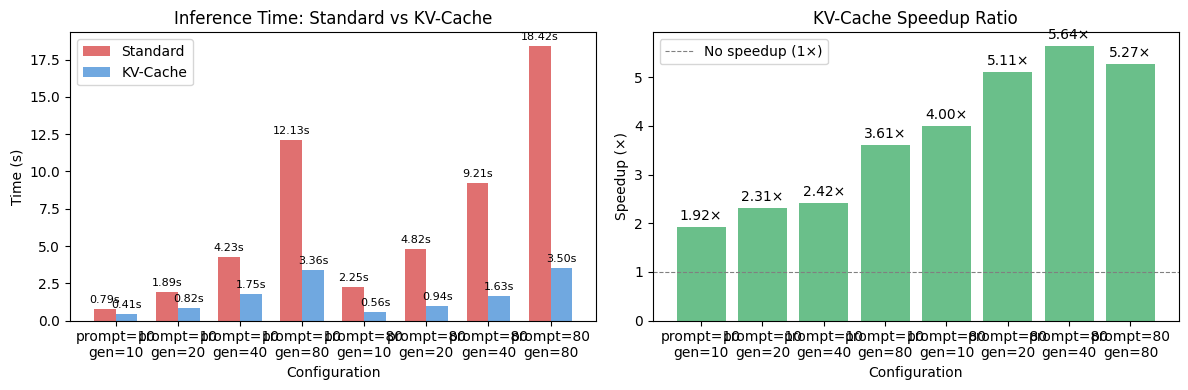

In [7]:
import matplotlib.pyplot as plt
import numpy as np

configs = [
    (10, 10),
    (10, 20),
    (10, 40),
    (10, 80),
    (80, 10),
    (80, 20),
    (80, 40),
    (80, 80), 
]
labels = [f"prompt={p}\ngen={g}" for p, g in configs]

std_times, cache_times = [], []
for p, g in configs:
    std_times.append(benchmark_inference(model, p, g, use_cache=False))
    cache_times.append(benchmark_inference(model, p, g, use_cache=True))

speedups = [s / c for s, c in zip(std_times, cache_times)]

x = np.arange(len(configs))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# --- Grouped bar: timing comparison ---
bars_std = ax1.bar(x - width / 2, std_times, width, label="Standard", color="#e07070")
bars_cache = ax1.bar(
    x + width / 2, cache_times, width, label="KV-Cache", color="#70a8e0"
)
ax1.set_xlabel("Configuration")
ax1.set_ylabel("Time (s)")
ax1.set_title("Inference Time: Standard vs KV-Cache")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.bar_label(bars_std, fmt="%.2fs", padding=3, fontsize=8)
ax1.bar_label(bars_cache, fmt="%.2fs", padding=3, fontsize=8)

# --- Speedup ratio ---
bars_sp = ax2.bar(x, speedups, color="#6abf8a")
ax2.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, label="No speedup (1×)")
ax2.set_xlabel("Configuration")
ax2.set_ylabel("Speedup (×)")
ax2.set_title("KV-Cache Speedup Ratio")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.bar_label(bars_sp, fmt="%.2f×", padding=3)

plt.tight_layout()
plt.savefig("kv_cache_benchmark.pdf", bbox_inches="tight")
plt.show()

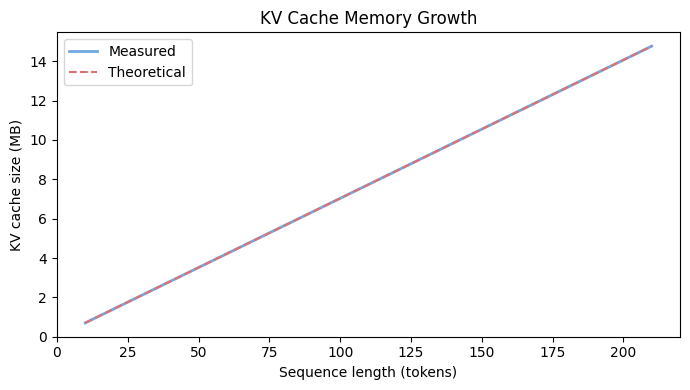

Per token:  72.0 KB
At 210 tokens:  14.77 MB measured, 14.77 MB theoretical


In [8]:
# KV Cache Memory Growth Experiment
#
# Goal: verify that KV cache memory grows linearly with sequence length,
# and that the actual size matches the theoretical formula:
#   2 × n_layers × n_heads × head_dim × seq_len × bytes_per_element
#
# The factor of 2 is because we store both K and V tensors per layer.


def measure_kv_cache_mb(kv_cache):
    """Sum the bytes across all K and V tensors in the cache."""
    total = 0
    for layer in kv_cache:
        # Each layer stores one K tensor and one V tensor.
        # .nelement() = total number of scalar values in the tensor
        # .element_size() = bytes per scalar (4 for float32)
        total += layer["key"].nelement()   * layer["key"].element_size()
        total += layer["value"].nelement() * layer["value"].element_size()
    return total / (1024 ** 2)  # convert bytes → MB


# --- Theoretical bytes added to the cache per new token ---
# Each layer stores K and V, both of shape (batch, n_heads, seq_len, head_dim).
# For a single new token: n_heads × head_dim floats per tensor × 2 tensors × n_layers
head_dim = GPT_CONFIG_124M["emb_dim"] // GPT_CONFIG_124M["n_heads"]  # 768 / 12 = 64
bytes_per_token = (
    2                                   # K and V
    * GPT_CONFIG_124M["n_layers"]       # one cache entry per transformer layer
    * GPT_CONFIG_124M["n_heads"]        # stored per attention head
    * head_dim                          # each head stores head_dim values
    * 4                                 # float32 = 4 bytes
)
# For this model: 2 × 12 × 12 × 64 × 4 = 73,728 bytes ≈ 72 KB per token

prompt_len = 10
max_new_tokens = 200
input_ids = torch.randint(0, 50257, (1, prompt_len)).to(device)

seq_lens, measured_mbs = [], []
kv_cache = None
current_context = input_ids

with torch.no_grad():
    # --- Prefill phase ---
    # Pass the entire prompt through the model in one shot.
    # The model computes K and V for all prompt tokens and stores them in kv_cache.
    # logits shape: (1, prompt_len, vocab_size) — one logit vector per prompt token.
    logits, kv_cache = model(current_context, kv_cache)
    seq_lens.append(prompt_len)
    measured_mbs.append(measure_kv_cache_mb(kv_cache))

    # --- Decode phase ---
    # At each step we feed only the single most-recent token.
    # The model appends its K and V to the existing cache instead of
    # recomputing the full sequence, which is the KV-cache speedup.
    for _ in range(max_new_tokens):
        # Feed just the last token — shape (1, 1)
        next_token = current_context[:, -1:]

        # Because input is 1 token, logits shape is (1, 1, vocab_size) —
        # the model only computes logits for the token(s) we passed in,
        # not for the entire cached history.
        logits, kv_cache = model(next_token, kv_cache)

        # Pick the highest-probability token as the next prediction.
        # logits[:, -1, :] → (batch, vocab_size)  [drop the seq dim first]
        # .argmax(keepdim=True) → (batch, 1)       [index of best token]
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        current_context = torch.cat([current_context, next_id], dim=1)

        seq_lens.append(seq_lens[-1] + 1)
        measured_mbs.append(measure_kv_cache_mb(kv_cache))

# Theoretical line: perfectly linear because each token adds a fixed number of bytes
theoretical_mbs = [s * bytes_per_token / (1024 ** 2) for s in seq_lens]

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(seq_lens, measured_mbs,    label="Measured",     color="#70a8e0", linewidth=2)
ax.plot(seq_lens, theoretical_mbs, label="Theoretical",  color="#e07070",
        linewidth=1.5, linestyle="--")
ax.set_xlabel("Sequence length (tokens)")
ax.set_ylabel("KV cache size (MB)")
ax.set_title("KV Cache Memory Growth")
ax.legend()
plt.tight_layout()
plt.savefig("kv_cache_memory.pdf", bbox_inches="tight")
plt.show()

print(f"Per token:  {bytes_per_token / 1024:.1f} KB")
print(f"At {seq_lens[-1]} tokens:  {measured_mbs[-1]:.2f} MB measured, "
      f"{theoretical_mbs[-1]:.2f} MB theoretical")